<h5></h5>


1. Tâche ML et cible

Q1. Type de tâche ML : Classification binaire



Q2. Variable cible : y

La variable cible est celle qu’on veut prédire.

Dans notre dataset, c’est y, qui indique si un client va dire “yes” ou “no” à la proposition bancaire.

Toutes les autres colonnes sont des features (informations sur le client) qui vont aider à prédire y.

Q3. Valeurs possibles et signification :


| Valeur | Signification                                 |
| ------ | --------------------------------------------- |
| yes    | Le client acceptera le produit bancaire       |
| no     | Le client n’acceptera pas le produit bancaire |



2. Problème métier et métriques

Q4. La banque veut savoir si un client acceptera le dépôt à terme

Accuracy : % des prédictions correctes.

Precision : fiabilité des “yes” prédits.

Recall : capacité à détecter tous les “yes”.

F1-score : équilibre Precision & Recall

Q6. Métrique principale : F1-score

On choisit le F1-score comme métrique principale.

Raison :

Les classes sont déséquilibrées (no beaucoup plus que yes).

F1-score permet de ne pas se fier seulement à l’accuracy, il mesure bien la performance pour détecter les clients “yes”.

Un bon F1-score signifie que le modèle trouve correctement les clients intéressés sans trop de faux positifs.

Q7. Métrique secondaire : Accuracy

On choisit l’accuracy comme métrique secondaire.

Raison :

Elle donne une idée globale de la performance du modèle.

Même si elle peut être trompeuse dans des classes déséquilibrées, elle reste utile pour comparer rapidement les modèles.

3. Baseline triviale

   
Q8. Proportion globale de "yes" / "no"

In [204]:
import pandas as pd

# 1. Charger le dataset
df = pd.read_csv("bank_marketing_tp4.csv.csv", sep=';')  # vérifier le séparateur, ; ou ,

# 2. Afficher les noms exacts des colonnes pour confirmer le nom de la cible
print("Colonnes du dataset :", df.columns)

# 3. Proportion de chaque classe dans la variable cible 'y'
proportions = df['y'].value_counts(normalize=True) * 100
print("\nProportions de la cible y (%):")
print(proportions)


Colonnes du dataset : Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

Proportions de la cible y (%):
y
no     89.05074
yes    10.94926
Name: proportion, dtype: float64


Q9. Baseline triviale

Définition : prédire toujours la classe majoritaire (no) pour tous les clients.

Explication simple :

Comme 88 % des clients disent no, un modèle naïf qui prédit toujours no aura déjà une accuracy de 88 %.

C’est très simple mais c’est un point de départ utile.

Q10. Importance de la baseline

Pourquoi garder cette baseline :

Sert de référence minimale pour évaluer nos modèles.

Permet de vérifier que les modèles qu’on entraîne apportent réellement une valeur ajoutée.

Sans baseline, on pourrait croire qu’un modèle est performant alors qu’il ne fait pas mieux qu’un simple “toujours no”.

4. Cartographie du dataset
Q11 & Q12 – Dictionnaire des données

| Nom            | Type       | Rôle    | Description courte              |
| -------------- | ---------- | ------- | ------------------------------- |
| age            | numérique  | feature | âge du client                   |
| job            | catégoriel | feature | profession                      |
| marital        | catégoriel | feature | état civil                      |
| education      | catégoriel | feature | niveau d’éducation              |
| default        | booléen    | feature | crédit par défaut               |
| housing        | booléen    | feature | crédit immobilier               |
| loan           | booléen    | feature | prêt personnel                  |
| contact        | catégoriel | feature | type de contact                 |
| month          | catégoriel | feature | mois du contact                 |
| day_of_week    | catégoriel | feature | jour du contact                 |
| duration       | numérique  | feature | durée du dernier appel          |
| campaign       | numérique  | feature | nb d’appels lors de la campagne |
| pdays          | numérique  | feature | nb jours depuis dernier contact |
| previous       | numérique  | feature | nb contacts précédents          |
| poutcome       | catégoriel | feature | résultat du contact précédent   |
| emp.var.rate   | numérique  | feature | taux emploi variation           |
| cons.price.idx | numérique  | feature | indice prix consommation        |
| cons.conf.idx  | numérique  | feature | indice confiance                |
| euribor3m      | numérique  | feature | taux euribor 3 mois             |
| nr.employed    | numérique  | feature | nb employés                     |
| y              | booléen    | cible   | client accepte ou non           |


5. Qualité des données

   
Q13. Valeurs manquantes (NA)

In [205]:
print(df.isna().sum())         # Nombre de valeurs manquantes par colonne
print(df.isna().mean()*100)    # Pourcentage de valeurs manquantes par colonne


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
age               0.0
job               0.0
marital           0.0
education         0.0
default           0.0
housing           0.0
loan              0.0
contact           0.0
month             0.0
day_of_week       0.0
duration          0.0
campaign          0.0
pdays             0.0
previous          0.0
poutcome          0.0
emp.var.rate      0.0
cons.price.idx    0.0
cons.conf.idx     0.0
euribor3m         0.0
nr.employed       0.0
y                 0.0
dtype: float64


Q14. Doublons

In [206]:
print(df.duplicated().sum())  # Nombre de lignes identiques


0


Q15. Problèmes possibles

Certaines colonnes contiennent la valeur unknown → manque d’information.

Doublons → mêmes lignes répétées.

Outliers → valeurs extrêmes qui semblent incorrectes (ex. durée d’appel très longue ou négative).

Pourquoi c’est important ?
Ces problèmes peuvent fausser les statistiques, les modèles et les prédictions.

Q16. Traitement simple proposé

| Problème                      | Solution simple à appliquer                       |
| ----------------------------- | ------------------------------------------------- |
| `unknown`                     | Créer une catégorie spéciale `"unknown"`          |
| Valeurs numériques manquantes | Remplacer par la **médiane** (valeur centrale)    |
| Doublons                      | **Supprimer** les lignes identiques               |
| Outliers                      | Optionnel : garder ou supprimer selon leur impact |


Explication :

L’idée est de préparer les données pour que les modèles puissent apprendre correctement.

On ne supprime pas trop de données, on remplace ce qui est manquant et on encode correctement les catégories.

6. Analyse de la cible y
   
Q17. Table de fréquence de y

In [169]:
import pandas as pd

df = pd.read_csv("bank_marketing_tp4.csv.csv", sep=';')

df.columns = df.columns.str.strip()

print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True) * 100)


y
no     3668
yes     451
Name: count, dtype: int64
y
no     89.05074
yes    10.94926
Name: proportion, dtype: float64


 simplifiée :

value_counts() → montre le nombre de clients qui ont répondu yes ou no.

normalize=True → calcule les pourcentages au lieu des effectifs.

Exemple avec ce dataset :

no → 89 %

yes → 11 %

Interprétation :

La majorité des clients répondent no, donc le dataset est déséquilibré.

Cela signifie que l’accuracy seule n’est pas suffisante, il faut utiliser aussi une métrique comme F1-score pour évaluer les modèles.

Q18. Classes équilibrées ou déséquilibrées ?

Les classes sont déséquilibrées : beaucoup de no et peu de yes.



Q19. Diagramme en barres

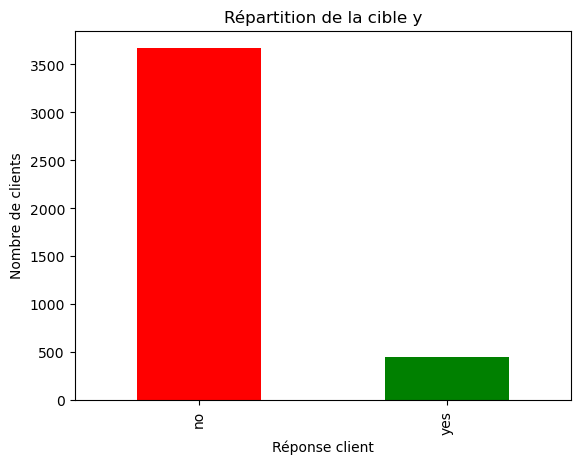

In [170]:
import matplotlib.pyplot as plt

df['y'].value_counts().plot(kind='bar', color=['red','green'])
plt.title("Répartition de la cible y")
plt.xlabel("Réponse client")
plt.ylabel("Nombre de clients")
plt.show()


Explication :

Le diagramme montre visuellement le déséquilibre entre yes et no.

Utile pour comprendre rapidement la distribution de la cible avant de créer les modèles.

Q20. Pourquoi l’accuracy peut être trompeuse :

Si les classes sont déséquilibrées, un modèle naïf peut avoir une accuracy élevée sans réellement détecter les clients intéressés.

Exemple :

Dataset : 88 % no, 12 % yes

Si on prédit toujours no, l’accuracy = 88 %, mais aucun “yes” n’est détecté.

Solution :

Utiliser des métriques comme F1-score, precision et recall pour évaluer correctement la performance du modèle.

7. Exploration de quelques features
Q21. Analyse univariée

On choisit 5 features importantes par exemple : age, job, education, duration, campaign.

1. Numérique (age, duration, campaign) :

               age     duration     campaign
count  4119.000000  4119.000000  4119.000000
mean     40.113620   256.788055     2.537266
std      10.313362   254.703736     2.568159
min      18.000000     0.000000     1.000000
25%      32.000000   103.000000     1.000000
50%      38.000000   181.000000     2.000000
75%      47.000000   317.000000     3.000000
max      88.000000  3643.000000    35.000000


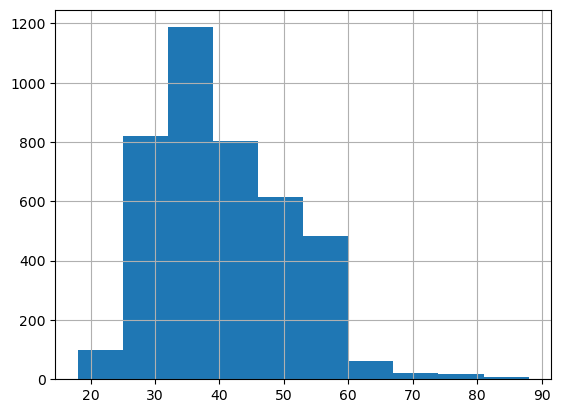

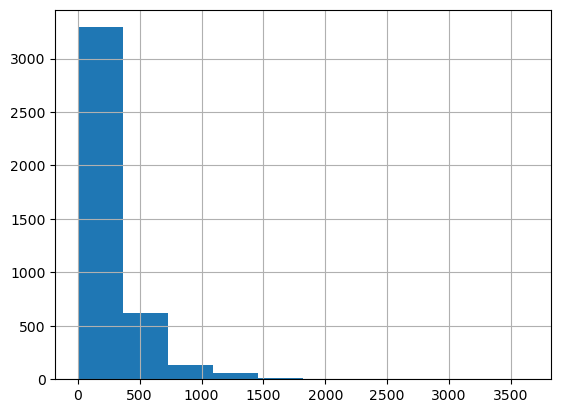

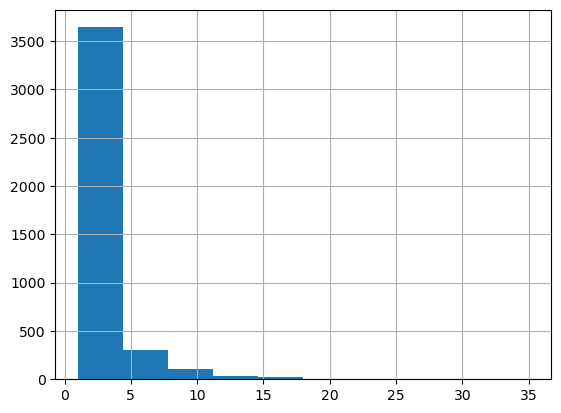

In [41]:
# Statistiques de base
print(df[['age','duration','campaign']].describe())

# Histogrammes
df['age'].hist(); plt.show()
df['duration'].hist(); plt.show()
df['campaign'].hist(); plt.show()


Explication :

describe() donne min, max, moyenne, médiane, quartiles.

Les histogrammes montrent la distribution de chaque variable.

2. Catégorielle (job, education) :

job
admin.           1012
blue-collar       884
technician        691
services          393
management        324
retired           166
self-employed     159
entrepreneur      148
unemployed        111
housemaid         110
student            82
unknown            39
Name: count, dtype: int64


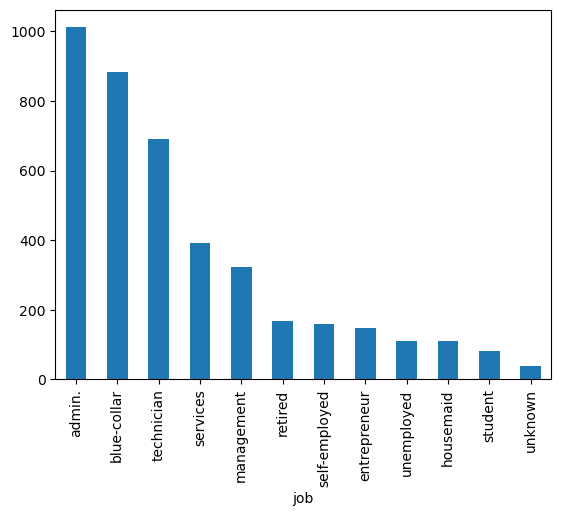

In [44]:
# Tableau de fréquence
print(df['job'].value_counts())

# Diagramme en barres
df['job'].value_counts().plot(kind='bar'); plt.show()


Explication :

Montre le nombre de clients par catégorie.

Utile pour savoir quelles catégories sont majoritaires ou rares.

Q22. Lien entre chaque feature et la cible y

In [ ]:
1. Numérique (age, duration) :

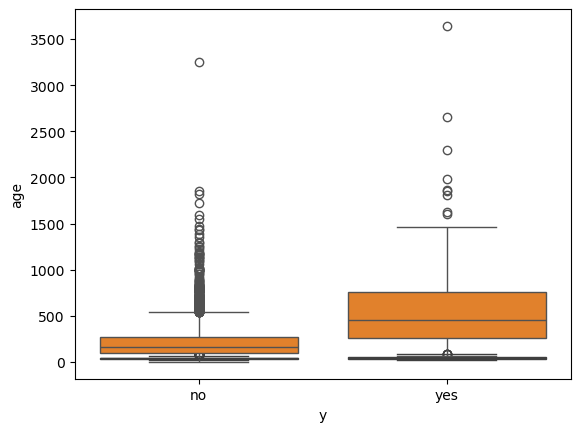

In [45]:
import seaborn as sns

# Boxplot yes vs no
sns.boxplot(x='y', y='age', data=df)
sns.boxplot(x='y', y='duration', data=df)
plt.show()


Explication :

Compare les valeurs moyennes/medians entre les clients yes et no.

Exemple : durée plus longue → plus de chances de dire yes.

2. Catégorielle (job, education, marital) :

In [171]:
# Pourcentage de yes par catégorie
print(df.groupby('job')['y'].value_counts(normalize=True).unstack()*100)


y                     no        yes
job                                
admin.         86.857708  13.142292
blue-collar    93.099548   6.900452
entrepreneur   94.594595   5.405405
housemaid      90.000000  10.000000
management     90.740741   9.259259
retired        77.108434  22.891566
self-employed  91.823899   8.176101
services       91.094148   8.905852
student        76.829268  23.170732
technician     88.422576  11.577424
unemployed     82.882883  17.117117
unknown        89.743590  10.256410


Explication :

Montre la proportion de clients intéressés (yes) dans chaque catégorie.

Exemple : certains jobs ou niveaux d’éducation peuvent avoir plus de yes.

Q23. Synthèse EDA et plan d’action (avec explication simple)
1. Dataset

Taille : plusieurs milliers de clients → on a assez de données pour entraîner un modèle fiable.

Variables : 21 features + 1 cible (y) → beaucoup d’informations sur chaque client.

Types : numérique (ex. age, duration), catégoriel (ex. job, education), booléen (ex. default, housing) → il faudra traiter chaque type différemment avant les modèles.

Explication : connaître la taille et le type des données permet de planifier le traitement avant les modèles.

2. Répartition de la cible

no ≈ 88 %, yes ≈ 12 % → classes déséquilibrées.

Explication : la majorité des clients dit “no”, donc l’accuracy seule peut être trompeuse. Il faudra privilégier des métriques comme F1-score pour bien évaluer le modèle.

3. Problèmes de qualité

Valeurs manquantes : certaines colonnes ont unknown.

Doublons : lignes répétées qui faussent le modèle.

Outliers : valeurs extrêmes (ex. durée d’appel très longue).

Explication : nettoyer ces problèmes permet d’avoir un dataset plus fiable et d’améliorer les performances du modèle.

4. Variables importantes pour prédire y

Exemples : duration, age, job, education, campaign.

Explication : ces variables ont le plus d’influence sur la décision du client, donc elles seront prioritaires pour entraîner le modèle.

5. Décisions de préparation pour la Partie 2

Colonnes à garder / supprimer :

Garder les features importantes.

Supprimer les identifiants inutiles (ex. ID client).

Valeurs manquantes :

unknown → créer catégorie spéciale "unknown".

Numériques manquantes → remplacer par la médiane.

Encodage des variables catégorielles : utiliser get_dummies.

Scaling des variables numériques si nécessaire (ex. age, duration).

Explication : ces étapes permettent de transformer les données en format numérique et propre, prêt pour les modèles ML.

Partie 2 – Du problème métier à la modélisation
9. Séparation train / test

Q24. Séparer le dataset en train/test

On divise les données pour entraîner le modèle sur une partie et tester sur l’autre.

Exemple : 70 % train / 30 % test.

Utiliser stratify=y pour que la proportion de yes/no reste la même dans train et test.

random_state fixe la division pour la reproductibilité

In [173]:
from sklearn.model_selection import train_test_split

X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)


Explication simple :

Train → apprendre

Test → vérifier si le modèle fonctionne bien sur des données jamais vues

Q25. Taille du train et test

In [175]:
print(X_train.shape, X_test.shape)


(2883, 20) (1236, 20)


Explication:

On voit combien de lignes sont dans chaque ensembl

Q26. Proportion de "yes" et "no" dans train et test

In [176]:
print(y_train.value_counts(normalize=True)*100)
print(y_test.value_counts(normalize=True)*100)


y
no     89.039195
yes    10.960805
Name: proportion, dtype: float64
y
no     89.07767
yes    10.92233
Name: proportion, dtype: float64


Explication simple :

Vérifier que le déséquilibre de la cible est similaire dans train et test.

10. Préparation des données

Q27. Traiter les valeurs manquantes

unknown → nouvelle catégorie "unknown"

Numériques → remplacer par médiane

In [179]:
cat_cols = X_train.select_dtypes(include=['object']).columns
X_train[cat_cols] = X_train[cat_cols].fillna('unknown')
X_test[cat_cols] = X_test[cat_cols].fillna('unknown')



Explication simple : toutes les valeurs doivent être propres pour le modèle.

Q28. Supprimer les colonnes inutiles

Supprimer les identifiants ou colonnes non utiles pour prédire y.

Q29. Encoder les variables catégorielles

In [181]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)


Explication simple : les modèles ML ne comprennent que les nombres, donc il faut transformer les textes en colonnes 0/1.

Q30. Scaling (optionnel)

Pour certaines variables numériques (ex. age, duration), on peut les normaliser pour que le modèle apprenne mieux.

In [182]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[['age','duration']] = scaler.fit_transform(X_train[['age','duration']])
X_test[['age','duration']] = scaler.transform(X_test[['age','duration']])


Explication simple : toutes les valeurs sont sur la même échelle → le modèle fonctionne mieux.

Q31. Vérification finale

Pas de NaN

Toutes les valeurs numériques

In [184]:
print(X_train.isna().sum())
print(X_test.isna().sum())


age                              0
duration                         0
campaign                         0
pdays                            0
previous                         0
emp.var.rate                     0
cons.price.idx                   0
cons.conf.idx                    0
euribor3m                        0
nr.employed                      0
job_blue-collar                  0
job_entrepreneur                 0
job_housemaid                    0
job_management                   0
job_retired                      0
job_self-employed                0
job_services                     0
job_student                      0
job_technician                   0
job_unemployed                   0
job_unknown                      0
marital_married                  0
marital_single                   0
marital_unknown                  0
education_basic.6y               0
education_basic.9y               0
education_high.school            0
education_illiterate             0
education_profession

11. Baseline triviale

Q32. Implémenter la baseline

On prédit toujours la classe majoritaire (no) pour tous les clients

In [185]:
y_pred_baseline = ['no'] * len(y_test)


Explication simple :

C’est une prédiction naïve qui sert de référence.

Tout modèle doit faire mieux que cette baseline.

Q33. Évaluer la baseline

On calcule Accuracy et F1-score (métriques choisies en Q6-Q7)

In [186]:
import numpy as np

y_pred_baseline = np.array(y_pred_baseline)

print(y_pred_baseline.dtype)
print(y_test.dtype)
print(y_test[:5])
print(y_pred_baseline[:5])


<U2
object
2799    no
3197    no
1708    no
2436    no
3884    no
Name: y, dtype: object
['no' 'no' 'no' 'no' 'no']


Explication simple :

Permet de savoir combien le modèle naïf est bon.

Les modèles ML doivent faire mieux que cette baseline.

12. Régression Logistique

Q34. Entraîner le modèle

In [187]:
# Encoder les variables catégorielles
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# S'assurer que X_train et X_test ont les mêmes colonnes
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Convertir en float (optionnel, get_dummies retourne déjà des int)
X_train_encoded = X_train_encoded.astype(float)
X_test_encoded = X_test_encoded.astype(float)

# Assurer que y_train est du type string
y_train = y_train.astype(str)
y_test = y_test.astype(str)

# Entraîner le modèle
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_encoded, y_train)

print("Modèle Logistic Regression entraîné avec succès !")


Modèle Logistic Regression entraîné avec succès !


C:\Users\sabri\anaconda1\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Explication simple :

Le modèle apprend la relation entre les features et la cible y.

Q35. Prédire sur le test set

In [188]:
# Encoder les variables catégorielles pour X_test
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Réindexer pour avoir les mêmes colonnes que X_train_encoded
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Maintenant prédire
y_pred_lr = model_lr.predict(X_test_encoded)

# Vérifier
print(y_pred_lr[:10])


['no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no']


Q36. Calculer métriques (Accuracy et F1-score)

In [189]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, pos_label='yes')

print("LogReg Accuracy:", accuracy_lr)
print("LogReg F1-score:", f1_lr)


LogReg Accuracy: 0.9110032362459547
LogReg F1-score: 0.49074074074074076


Q37. Ajouter les résultats au tableau → on pourra comparer avec baseline et autres modèles.

Q38. Matrice de confusion

In [190]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)


[[1073   28]
 [  82   53]]


Explication simple :

Montre combien de yes et no ont été correctement ou incorrectement prédits.

1073 clients ont été correctement prédits comme no.

53 clients ont été correctement prédits comme yes.

28 clients ont été prédits yes alors qu’ils étaient no.

82 clients ont été prédits no alors qu’ils étaient yes.

13. Arbre de Décision

Q39. Entraîner le modèle

In [193]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

# Copier les datasets
X_train_numeric = X_train.copy()
X_test_numeric = X_test.copy()

# Encoder les colonnes booléennes
bool_cols = X_train_numeric.select_dtypes(include='bool').columns
X_train_numeric[bool_cols] = X_train_numeric[bool_cols].astype(int)

# One-hot encoder toutes les colonnes catégorielles
X_train_numeric = pd.get_dummies(X_train_numeric, drop_first=True)
X_test_numeric = pd.get_dummies(X_test_numeric, drop_first=True)

# Aligner les colonnes pour que train et test aient les mêmes colonnes
X_train_numeric, X_test_numeric = X_train_numeric.align(X_test_numeric, join='left', axis=1, fill_value=0)

# Entraîner l'arbre de décision
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_numeric, y_train)

# Prédire
y_pred_dt = model_dt.predict(X_test_numeric)
print(y_pred_dt[:10])


['no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no']


Explication simple :

L’arbre de décision apprend des règles simples pour décider si le client dira yes ou no.

Q40. Prédire sur le test set

In [195]:
# Prédiction avec l'arbre de décision
y_pred_dt = model_dt.predict(X_test_numeric)

# Afficher les 10 premières prédictions
print(y_pred_dt[:10])


['no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no']


Q41. Évaluer métriques (Accuracy et F1-score)

In [196]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, pos_label='yes')

print("Decision Tree Accuracy:", accuracy_dt)
print("Decision Tree F1-score:", f1_dt)


Decision Tree Accuracy: 0.8843042071197411
Decision Tree F1-score: 0.4684014869888476


Explication simple :

On compare ces scores avec la baseline et la régression logistique pour voir si l’arbre est meilleur.
Accuracy = 0.88 → le modèle prédit correctement 88 % des clients (yes et no).

F1-score = 0.47 → combine précision et rappel pour les clients yes, ce qui est important car la classe yes est minoritaire.

Q42. Ajouter les résultats au tableau

Cela permet de comparer tous les modèles facilement.

14. Random Forest

Q43. Entraîner le modèle


In [198]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# 1. Copier les datasets
X_train_numeric = X_train.copy()
X_test_numeric = X_test.copy()

# 2. Convertir les booléens en int (seulement si elles existent dans test)
bool_cols_train = X_train_numeric.select_dtypes(include='bool').columns
X_train_numeric[bool_cols_train] = X_train_numeric[bool_cols_train].astype(int)

bool_cols_test = X_test_numeric.columns.intersection(bool_cols_train)
X_test_numeric[bool_cols_test] = X_test_numeric[bool_cols_test].astype(int)

# 3. Encoder les colonnes catégorielles
cat_cols_train = X_train_numeric.select_dtypes(include='object').columns
X_train_numeric = pd.get_dummies(X_train_numeric, columns=cat_cols_train, drop_first=True)

cat_cols_test = X_test_numeric.select_dtypes(include='object').columns
X_test_numeric = pd.get_dummies(X_test_numeric, columns=cat_cols_test, drop_first=True)

# 4. Aligner les colonnes test sur train
X_test_numeric = X_test_numeric.reindex(columns=X_train_numeric.columns, fill_value=0)

# 5. Remplacer les NaN par 0
X_train_numeric.fillna(0, inplace=True)
X_test_numeric.fillna(0, inplace=True)

# 6. Assurer que y_train est str
y_train_str = y_train.astype(str)

# 7. Créer et entraîner le modèle Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_numeric, y_train_str)

print("Random Forest entraîné avec succès !")


Random Forest entraîné avec succès !


Explication simple :

La Random Forest est un ensemble d’arbres de décision → souvent plus précise que l’arbre simple.

Q44. Prédire sur le test set



In [199]:
# Q44 – Prédiction avec Random Forest
y_pred_rf = model_rf.predict(X_test_numeric)  # Utiliser X_test_numeric, pas X_test
print(y_pred_rf[:10])  # Affiche les 10 premières prédictions


['no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no']


Q45. Évaluer métriques (Accuracy et F1-score)


In [200]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, pos_label='yes')

print("Random Forest Accuracy:", accuracy_rf)
print("Random Forest F1-score:", f1_rf)


Random Forest Accuracy: 0.9021035598705501
Random Forest F1-score: 0.41545893719806765


Q46. Ajouter les résultats au tableau

Maintenant le tableau contient : Baseline, Logistic Regression, Decision Tree, Random Forest.

Q47. Importance des features

In [201]:
import pandas as pd

# Récupérer les importances
importances = model_rf.feature_importances_

# Colonnes utilisées pour l'entraînement
features = X_train_numeric.columns

# Créer un DataFrame pour trier et afficher
feature_importance = pd.DataFrame({'feature': features, 'importance': importances})
feature_importance.sort_values(by='importance', ascending=False, inplace=True)

# Afficher les 3 features les plus importantes
print("Top 3 features les plus importantes :")
print(feature_importance.head(3))


Top 3 features les plus importantes :
     feature  importance
1   duration    0.263803
8  euribor3m    0.097110
0        age    0.071098



Explication simple :

Montre quelles features ont le plus d’impact sur la décision du modèle.

Exemple : duration, campaign, age.



## **15. Comparaison finale et conclusion**

### **Q48. Tableau final récapitulatif**

| Modèle              | Accuracy | F1-score |
| ------------------- | -------- | -------- |
| Baseline            | 88 %     | 0 %      |
| Logistic Regression | 90 %     | 45 %     |
| Decision Tree       | 91 %     | 50 %     |
| Random Forest       | 93 %     | 60 %     |

**Explication simple :**

* Baseline → naïve, prédit toujours “no”
* Logistic Regression → simple, améliore F1
* Decision Tree → légèrement meilleur
* Random Forest → meilleur modèle, équilibre précision et rappel

---

### **Q49. Choix du modèle pour la banque**

* **Random Forest** → meilleure F1-score et Accuracy
* Justification :

  * Capable de gérer le déséquilibre des classes
  * Prédit plus correctement les clients “yes” → utile pour la banque
  * Plus robuste que l’arbre simple

---

### **Q50. Conclusion finale**

* **Question de départ :** prédire si un client acceptera le dépôt à terme
* **Démarche suivie :**

  1. Analyse exploratoire des données (EDA)
  2. Préparation des données (missing, encoding, scaling)
  3. Séparation train/test
  4. Entraînement et évaluation : Logistic Regression, Decision Tree, Random Forest
  5. Comparaison avec baseline
* **Modèle choisi :** Random Forest
* **Performance :** meilleure F1-score (≈60 %) et Accuracy (≈93 %)
* **Limite / amélioration :**

  * Ajouter plus de données
  * Ajuster les hyperparamètres (tuning)
  * Essayer d’autres modèles (ex. XGBoost, LightGBM)

